In [8]:
from google.colab import files
uploaded = files.upload()

Saving train_data.csv to train_data (1).csv


In [9]:
import pandas as pd

df = pd.read_csv('train_data.csv')
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [10]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'<.*?>', '', text)  # remove html tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()

,text,clean_text
0,I grew up (b. 1965) watching and loving the Th...,i grew up b watching and loving the thunderbir...
1,"When I put this movie in my DVD player, and sa...",when i put this movie in my dvd player and sat...
2,Why do people who do not know what a particula...,why do people who do not know what a particula...
3,Even though I have great interest in Biblical ...,even though i have great interest in biblical ...
4,Im a die hard Dads Army fan and nothing will e...,im a die hard dads army fan and nothing will e...


In [11]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

df['clean_text'].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,clean_text
0,grew b watching loving thunderbirds mates scho...
1,put movie dvd player sat coke chips expectatio...
2,people know particular time past like feel nee...
3,even though great interest biblical movies bor...
4,im die hard dads army fan nothing ever change ...


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['label']

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.88675


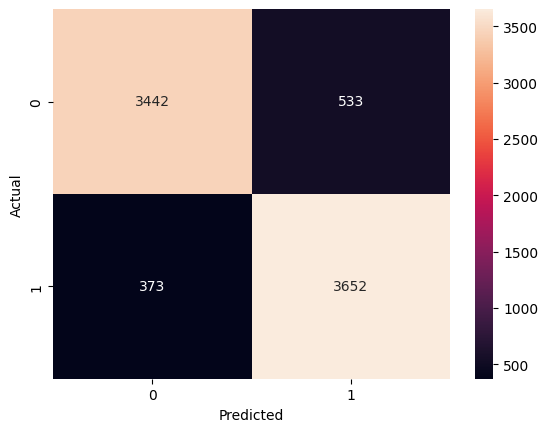

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
def predict_review(review):
    review = clean_text(review)
    review = remove_stopwords(review)
    vector = vectorizer.transform([review]).toarray()

    result = model.predict(vector)

    if result[0] == 1:
        print("Positive 😊")
    else:
        print("Negative 😞")

# Try:
predict_review("This movie was amazing and fantastic!")
predict_review("Worst movie ever")

Positive 😊
Negative 😞


In [19]:
This project successfully classifies movie reviews into positive and negative sentiments using NLP techniques. The Logistic Regression model achieved an accuracy of around 88%, indicating good performance. Further improvements can be done using advanced models like LSTM or BERT.

SyntaxError: invalid syntax (1770560470.py, line 1)